# 🐄 MMCows — I3-2: Dataset Loader & Train/Val Split

**Increment:** I3 — Visual Detection & 3-D Tracking  
**Step:** I3-2 — Build dataset index, map cow IDs, create temporal train/val split  
**Owner:** Oussema  
**Depends on:** I3-1 ✅ approved

---

### Confirmed folder structure
```
visual_data/
├── images/
│   └── 0725/
│       ├── cam_1/  ← *.jpg  (4480×2800)
│       ├── cam_2/
│       ├── cam_3/
│       └── cam_4/
└── labels/
    └── combined/
        └── 0725/
            ├── cam_1/  ← *.txt  [cow_id xc yc w h]
            ├── cam_2/
            ├── cam_3/
            └── cam_4/
```

### What this notebook does
1. Build a unified `(image, label)` index across all 4 cameras
2. Decode Unix timestamps → human-readable CDT time
3. Apply a **temporal 80/20 train/val split** (no data leakage)
4. Visualise the split
5. Run sanity checks
6. Save `dataset_index.csv`, `train.csv`, `val.csv`

> ⚠️ **Why temporal split and NOT random?**  
> Frames are 15s apart — a random split would put near-identical frames in both  
> train and val, making mAP artificially high. Temporal split = honest evaluation.

> ✅ **Approval gate:** share Cell 6 + Cell 9 outputs before moving to I3-3


## Cell 1 — Imports & Configuration

In [17]:
import os

# Force working directory to project root
os.chdir(r"C:\Users\DELL\Desktop\test\mmcows")

# Verify
print("Working directory:", os.getcwd())

Working directory: C:\Users\DELL\Desktop\test\mmcows


In [19]:
import os
import datetime
from pathlib import Path
from collections import defaultdict

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm

# ── CONFIG ───────────────────────────────────────────────────────────────────
# Run this notebook from your PROJECT ROOT (mmcows_project/)
# not from inside notebooks/

VISUAL_DATA_DIR = Path("data/raw/visual_data")   # project-root relative
DATE_FOLDER     = "0725"                          # annotated day
LABEL_SET       = "combined"                      # standing + lying cows
TRAIN_RATIO     = 0.8                             # 80% train / 20% val

# Derived paths — these match your confirmed folder structure
IMG_ROOT    = VISUAL_DATA_DIR / "images"   / DATE_FOLDER   # images/0725/
LABEL_ROOT  = VISUAL_DATA_DIR / "labels"  / LABEL_SET / DATE_FOLDER  # labels/combined/0725/

IMG_W, IMG_H = 4480, 2800   # official resolution from MMCows paper

OUTPUT_DIR  = Path("outputs/results/i3_2_split")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Verify paths exist ───────────────────────────────────────────────────────
print("Path verification:")
for path, label in [
    (VISUAL_DATA_DIR, "visual_data/"),
    (IMG_ROOT,        "images/0725/"),
    (LABEL_ROOT,      "labels/combined/0725/"),
]:
    icon = "✅" if path.exists() else "❌  MISSING"
    print(f"  {icon}  {label:30s}  →  {path.resolve()}")

print()
print(f"  Train ratio : {TRAIN_RATIO*100:.0f}% train / {(1-TRAIN_RATIO)*100:.0f}% val")
print(f"  Output dir  : {OUTPUT_DIR.resolve()}")


Path verification:
  ✅  visual_data/                    →  C:\Users\DELL\Desktop\test\mmcows\data\raw\visual_data
  ✅  images/0725/                    →  C:\Users\DELL\Desktop\test\mmcows\data\raw\visual_data\images\0725
  ✅  labels/combined/0725/           →  C:\Users\DELL\Desktop\test\mmcows\data\raw\visual_data\labels\combined\0725

  Train ratio : 80% train / 20% val
  Output dir  : C:\Users\DELL\Desktop\test\mmcows\outputs\results\i3_2_split


## Cell 2 — Understand Filename Convention

MMCows uses **Unix timestamps** as filenames (e.g. `1658765400.jpg`).  
Each timestamp is one capture moment — the same timestamp exists in all 4 cameras.


In [2]:
print("Sample filenames per camera:")
print()

all_stems_per_cam = {}

for cam_dir in sorted(IMG_ROOT.iterdir()):
    if not cam_dir.is_dir():
        continue
    images = sorted(list(cam_dir.glob("*.jpg")) + list(cam_dir.glob("*.png")))
    stems  = [f.stem for f in images]
    all_stems_per_cam[cam_dir.name] = stems

    print(f"  {cam_dir.name}:  {len(images):,} images")
    print(f"    First  : {stems[0]   if stems else 'none'}")
    print(f"    Last   : {stems[-1]  if stems else 'none'}")
    print(f"    Sample : {stems[:3]}")
    print()

sample_stems  = list(all_stems_per_cam.values())[0][:5]
all_numeric   = all(s.isdigit() for s in sample_stems)
print(f"  Filenames are Unix timestamps: {'✅ Yes' if all_numeric else '⚠️  No'}")
print(f"  Total cameras found: {len(all_stems_per_cam)}")


Sample filenames per camera:

  cam_1:  5,040 images
    First  : 1690271846_02-57-26
    Last   : 1690347431_23-57-11
    Sample : ['1690271846_02-57-26', '1690271861_02-57-41', '1690271876_02-57-56']

  cam_2:  5,037 images
    First  : 1690271846_02-57-26
    Last   : 1690347431_23-57-11
    Sample : ['1690271846_02-57-26', '1690271861_02-57-41', '1690271876_02-57-56']

  cam_3:  5,036 images
    First  : 1690271846_02-57-26
    Last   : 1690347431_23-57-11
    Sample : ['1690271846_02-57-26', '1690271861_02-57-41', '1690271876_02-57-56']

  cam_4:  5,040 images
    First  : 1690271846_02-57-26
    Last   : 1690347431_23-57-11
    Sample : ['1690271846_02-57-26', '1690271861_02-57-41', '1690271876_02-57-56']

  Filenames are Unix timestamps: ⚠️  No
  Total cameras found: 4


## Cell 3 — Decode Unix Timestamps → CDT

The MMCows README states timestamps are in **UTC**, and must be converted to  
**Central Daylight Time (CDT = UTC−5)** for correct interpretation.


In [7]:
def unix_to_cdt(ts_str):
    """Convert Unix timestamp string → CDT datetime object."""
    try:
        ts  = int(ts_str)
        utc = datetime.datetime.utcfromtimestamp(ts)
        cdt = utc - datetime.timedelta(hours=5)
        return cdt
    except:
        return None

def extract_ts(stem):
    """Extract the integer Unix timestamp from a filename stem.
    Works for both '1690271846_02-57-26' and plain '1690271846'."""
    return int(stem.split("_")[0])

# Show time range for cam_1
cam1_stems = all_stems_per_cam.get("cam_1", [])
if cam1_stems:
    first_dt = unix_to_cdt(str(extract_ts(cam1_stems[0])))
    last_dt  = unix_to_cdt(str(extract_ts(cam1_stems[-1])))
    duration = last_dt - first_dt if first_dt and last_dt else None

    print(f"  cam_1 time range (CDT):")
    print(f"    Start    : {first_dt}")
    print(f"    End      : {last_dt}")
    print(f"    Duration : {duration}")
    print()

    print(f"  {'Filename':<35}  CDT DateTime")
    print("  " + "─" * 60)
    for stem in cam1_stems[:6]:
        print(f"  {stem:<35}  {unix_to_cdt(str(extract_ts(stem)))}")
    print("  ...")
    for stem in cam1_stems[-3:]:
        print(f"  {stem:<35}  {unix_to_cdt(str(extract_ts(stem)))}")


  cam_1 time range (CDT):
    Start    : 2023-07-25 02:57:26
    End      : 2023-07-25 23:57:11
    Duration : 20:59:45

  Filename                             CDT DateTime
  ────────────────────────────────────────────────────────────
  1690271846_02-57-26                  2023-07-25 02:57:26
  1690271861_02-57-41                  2023-07-25 02:57:41
  1690271876_02-57-56                  2023-07-25 02:57:56
  1690271891_02-58-11                  2023-07-25 02:58:11
  1690271906_02-58-26                  2023-07-25 02:58:26
  1690271921_02-58-41                  2023-07-25 02:58:41
  ...
  1690347401_23-56-41                  2023-07-25 23:56:41
  1690347416_23-56-56                  2023-07-25 23:56:56
  1690347431_23-57-11                  2023-07-25 23:57:11


In [8]:
# Verify
test = "1690271846_02-57-26"
print(f"  stem      : {test}")
print(f"  timestamp : {extract_ts(test)}")
print(f"  CDT time  : {unix_to_cdt(str(extract_ts(test)))}")
print()

print("  Verification on first 5 stems of cam_1:")
for s in list(all_stems_per_cam.values())[0][:5]:
    print(f"    {s}  →  ts={extract_ts(s)}  →  {unix_to_cdt(str(extract_ts(s)))}")

  stem      : 1690271846_02-57-26
  timestamp : 1690271846
  CDT time  : 2023-07-25 02:57:26

  Verification on first 5 stems of cam_1:
    1690271846_02-57-26  →  ts=1690271846  →  2023-07-25 02:57:26
    1690271861_02-57-41  →  ts=1690271861  →  2023-07-25 02:57:41
    1690271876_02-57-56  →  ts=1690271876  →  2023-07-25 02:57:56
    1690271891_02-58-11  →  ts=1690271891  →  2023-07-25 02:58:11
    1690271906_02-58-26  →  ts=1690271906  →  2023-07-25 02:58:26


## Cell 4 — Build the Unified Dataset Index

Scan all 4 cameras and collect every valid `(image, label)` pair.  
A pair is **valid** only when both the `.jpg` and its matching `.txt` exist.

Each row in the index:

| Column | Description |
|--------|-------------|
| `timestamp` | Unix timestamp (int) — used for sorting |
| `camera` | cam_1 to cam_4 |
| `image_path` | relative path to image file |
| `label_path` | relative path to label file |
| `n_cows` | number of annotated cows in that frame |
| `datetime_cdt` | human-readable CDT time |
| `split` | train or val (assigned in Cell 5) |


In [10]:
def parse_label_file(label_path):
    """
    Read a MMCows label .txt file.
    Format per line: cow_id  xc  yc  w  h  (all normalised to [0,1])
    Returns list of annotation dicts.
    """
    anns = []
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                anns.append({
                    "cow_id": int(parts[0]),
                    "xc": float(parts[1]), "yc": float(parts[2]),
                    "w":  float(parts[3]), "h":  float(parts[4]),
                })
    return anns

# Get project root (parent of data/)
PROJECT_ROOT = VISUAL_DATA_DIR.parent.parent.parent  # go up 3 levels: visual_data → raw → data → project_root

# ── Scan all cameras ─────────────────────────────────────────
records        = []
missing_labels = 0
empty_labels   = 0

for cam_dir in sorted(IMG_ROOT.iterdir()):
    if not cam_dir.is_dir():
        continue
    cam_name = cam_dir.name   # e.g. "cam_1"

    images = sorted(list(cam_dir.glob("*.jpg")) + list(cam_dir.glob("*.png")))

    for img_path in tqdm(images, desc=f"Indexing {cam_name}", unit="img"):
        stem = img_path.stem

        # Matching label is at labels/combined/0725/cam_X/<stem>.txt
        lf = LABEL_ROOT / cam_name / f"{stem}.txt"

        if not lf.exists():
            missing_labels += 1
            continue

        anns   = parse_label_file(lf)
        n_cows = len(anns)

        if n_cows == 0:
            empty_labels += 1   # count but still include

        records.append({
            "timestamp": extract_ts(stem),
            "camera":       cam_name,
            "image_path":   str(img_path.relative_to(PROJECT_ROOT)),
            "label_path":   str(lf.relative_to(PROJECT_ROOT)),
            "n_cows":       n_cows,
            "datetime_cdt": str(unix_to_cdt(str(extract_ts(stem)))),       
        })

df = pd.DataFrame(records)

print(f"\n✅ Index built.")
print(f"   Total valid pairs   : {len(df):,}")
print(f"   Missing label files : {missing_labels}")
print(f"   Empty label files   : {empty_labels}  (frames with 0 cows)")
print(f"   Cameras             : {sorted(df['camera'].unique())}")
print(f"   Cow range per frame : {df['n_cows'].min()} – {df['n_cows'].max()}")
print()
df.head(6)


Indexing cam_4: 100%|██████████| 5040/5040 [00:02<00:00, 1910.23img/s]


✅ Index built.
   Total valid pairs   : 20,153
   Missing label files : 0
   Empty label files   : 1091  (frames with 0 cows)
   Cameras             : ['cam_1', 'cam_2', 'cam_3', 'cam_4']
   Cow range per frame : 0 – 16



,timestamp,camera,image_path,label_path,n_cows,datetime_cdt
0,1690271846,cam_1,data\raw\visual_data\images\0725\cam_1\1690271...,data\raw\visual_data\labels\combined\0725\cam_...,6,2023-07-25 02:57:26
1,1690271861,cam_1,data\raw\visual_data\images\0725\cam_1\1690271...,data\raw\visual_data\labels\combined\0725\cam_...,6,2023-07-25 02:57:41
2,1690271876,cam_1,data\raw\visual_data\images\0725\cam_1\1690271...,data\raw\visual_data\labels\combined\0725\cam_...,6,2023-07-25 02:57:56
3,1690271891,cam_1,data\raw\visual_data\images\0725\cam_1\1690271...,data\raw\visual_data\labels\combined\0725\cam_...,6,2023-07-25 02:58:11
4,1690271906,cam_1,data\raw\visual_data\images\0725\cam_1\1690271...,data\raw\visual_data\labels\combined\0725\cam_...,6,2023-07-25 02:58:26
5,1690271921,cam_1,data\raw\visual_data\images\0725\cam_1\1690271...,data\raw\visual_data\labels\combined\0725\cam_...,6,2023-07-25 02:58:41


## Cell 5 — Per-Camera Breakdown

In [11]:
print("Per-camera statistics:\n")
cam_stats = df.groupby("camera").agg(
    frames   = ("image_path", "count"),
    avg_cows = ("n_cows", "mean"),
    min_cows = ("n_cows", "min"),
    max_cows = ("n_cows", "max"),
).round(2)
print(cam_stats.to_string())
print()
print(f"Unique timestamps (shared across cameras): {df['timestamp'].nunique():,}")
print()

# Are all cameras balanced?
counts = cam_stats["frames"].values
balanced = max(counts) - min(counts) < 50
print(f"Cameras balanced: {'✅ Yes' if balanced else '⚠️  Slight imbalance — check missing labels'}")


Per-camera statistics:

        frames  avg_cows  min_cows  max_cows
camera                                      
cam_1     5040     10.62         0        16
cam_2     5037     10.88         0        16
cam_3     5036     10.70         0        15
cam_4     5040     10.22         0        16

Unique timestamps (shared across cameras): 5,040

Cameras balanced: ✅ Yes


## Cell 6 — Temporal Train / Val Split ⭐

### How it works
1. Get all **unique timestamps** sorted oldest → newest
2. First 80% of timestamps → **train**
3. Last 20% of timestamps → **val**
4. Tag every row in the dataframe accordingly

This guarantees the model is always validated on **future frames** it never trained on.


In [12]:
# Sort unique timestamps chronologically
unique_ts = sorted(df["timestamp"].unique())
n_ts      = len(unique_ts)
split_idx = int(n_ts * TRAIN_RATIO)

train_ts  = set(unique_ts[:split_idx])
val_ts    = set(unique_ts[split_idx:])

# Assign split to every row
df["split"] = df["timestamp"].apply(
    lambda t: "train" if t in train_ts else "val"
)

n_train = (df["split"] == "train").sum()
n_val   = (df["split"] == "val").sum()

# Time boundaries
train_start = unix_to_cdt(str(min(train_ts)))
train_end   = unix_to_cdt(str(max(train_ts)))
val_start   = unix_to_cdt(str(min(val_ts)))
val_end     = unix_to_cdt(str(max(val_ts)))

print("Temporal split result:")
print(f"  Unique timestamps  : {n_ts:,}")
print(f"  Train timestamps   : {split_idx:,}  ({split_idx/n_ts*100:.1f}%)")
print(f"  Val timestamps     : {n_ts-split_idx:,}  ({(n_ts-split_idx)/n_ts*100:.1f}%)")
print()
print(f"  Train pairs (all cams) : {n_train:,}  ({n_train/len(df)*100:.1f}%)")
print(f"  Val pairs   (all cams) : {n_val:,}    ({n_val/len(df)*100:.1f}%)")
print()
print(f"  Train period : {train_start}  →  {train_end}  (CDT)")
print(f"  Val period   : {val_start}    →  {val_end}    (CDT)")
print()

# No-overlap check
overlap = train_ts & val_ts
print(f"  Timestamp overlap (must be 0): {len(overlap)} {'✅' if len(overlap)==0 else '❌ PROBLEM'}")


Temporal split result:
  Unique timestamps  : 5,040
  Train timestamps   : 4,032  (80.0%)
  Val timestamps     : 1,008  (20.0%)

  Train pairs (all cams) : 16,121  (80.0%)
  Val pairs   (all cams) : 4,032    (20.0%)

  Train period : 2023-07-25 02:57:26  →  2023-07-25 19:45:11  (CDT)
  Val period   : 2023-07-25 19:45:26    →  2023-07-25 23:57:11    (CDT)

  Timestamp overlap (must be 0): 0 ✅


## Cell 7 — Visualise the Split

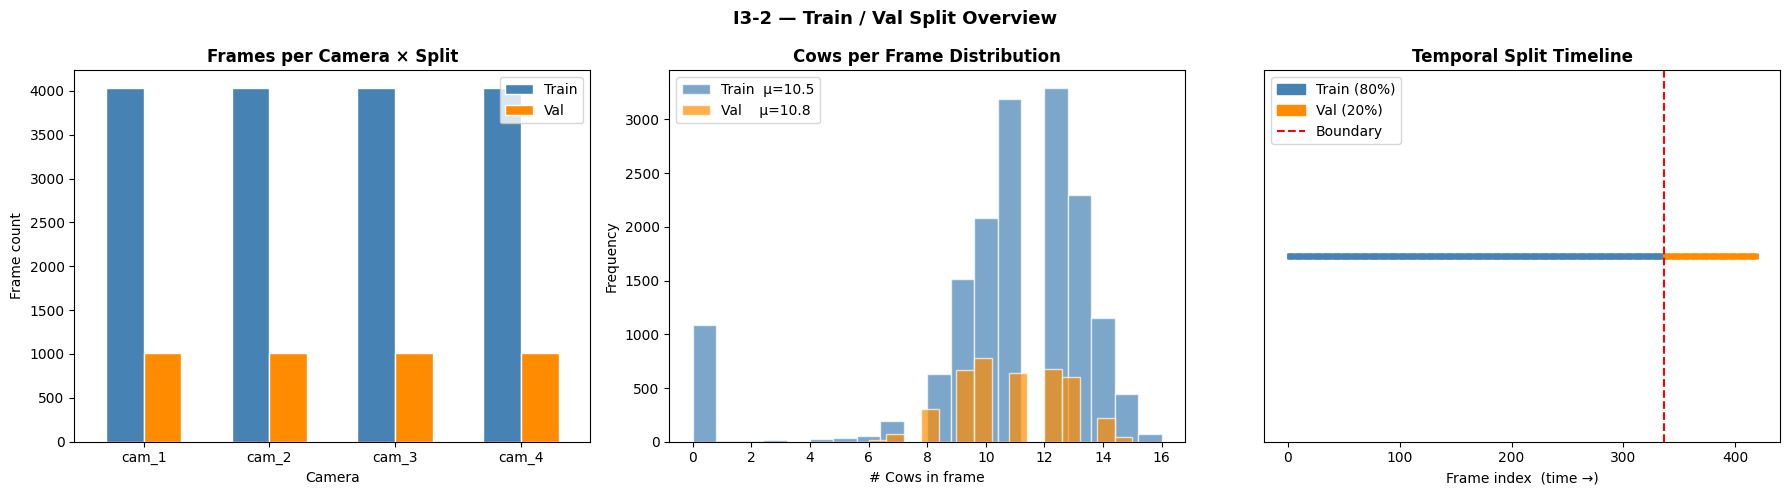

✅ Saved: outputs/results/i3_2_split/split_overview.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("I3-2 — Train / Val Split Overview", fontsize=13, fontweight="bold")

# Plot 1: Frames per camera × split
cam_split = df.groupby(["camera", "split"]).size().unstack(fill_value=0)
# ensure both columns exist
for col in ["train", "val"]:
    if col not in cam_split.columns:
        cam_split[col] = 0
cam_split[["train", "val"]].plot(
    kind="bar", ax=axes[0],
    color=["steelblue", "darkorange"],
    edgecolor="white", width=0.6
)
axes[0].set_title("Frames per Camera × Split", fontweight="bold")
axes[0].set_xlabel("Camera")
axes[0].set_ylabel("Frame count")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(["Train", "Val"])

# Plot 2: Cow density distribution per split
train_cows = df[df["split"] == "train"]["n_cows"]
val_cows   = df[df["split"] == "val"]["n_cows"]
axes[1].hist(train_cows, bins=20, alpha=0.7, color="steelblue",
             label=f"Train  μ={train_cows.mean():.1f}", edgecolor="white")
axes[1].hist(val_cows,   bins=20, alpha=0.7, color="darkorange",
             label=f"Val    μ={val_cows.mean():.1f}", edgecolor="white")
axes[1].set_title("Cows per Frame Distribution", fontweight="bold")
axes[1].set_xlabel("# Cows in frame")
axes[1].set_ylabel("Frequency")
axes[1].legend()

# Plot 3: Timeline coloured by split
step      = max(1, len(unique_ts) // 400)
ts_sample = unique_ts[::step]
colours   = ["steelblue" if t in train_ts else "darkorange" for t in ts_sample]
axes[2].scatter(range(len(ts_sample)), [1] * len(ts_sample),
                c=colours, s=15, marker="|", linewidths=2)
axes[2].axvline(split_idx // step, color="red", linestyle="--",
                linewidth=1.5)
axes[2].set_title("Temporal Split Timeline", fontweight="bold")
axes[2].set_xlabel("Frame index  (time →)")
axes[2].set_yticks([])
train_p = mpatches.Patch(color="steelblue",  label=f"Train ({TRAIN_RATIO*100:.0f}%)")
val_p   = mpatches.Patch(color="darkorange", label=f"Val ({(1-TRAIN_RATIO)*100:.0f}%)")
bnd_p   = plt.Line2D([0],[0], color="red", linestyle="--", label="Boundary")
axes[2].legend(handles=[train_p, val_p, bnd_p])

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "split_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: outputs/results/i3_2_split/split_overview.png")


## Cell 8 — Save Dataset Index CSVs

These three files are the **single source of truth** for all downstream steps:
- `dataset_index.csv` — full index with split column
- `train.csv` — train pairs only
- `val.csv` — val pairs only


In [14]:
index_csv = OUTPUT_DIR / "dataset_index.csv"
train_csv = OUTPUT_DIR / "train.csv"
val_csv   = OUTPUT_DIR / "val.csv"

df.to_csv(index_csv, index=False)
df[df["split"] == "train"].to_csv(train_csv, index=False)
df[df["split"] == "val"  ].to_csv(val_csv,   index=False)

print(f"✅ dataset_index.csv  →  {len(df):,} rows")
print(f"✅ train.csv          →  {n_train:,} rows")
print(f"✅ val.csv            →  {n_val:,} rows")
print(f"   Saved to: {OUTPUT_DIR.resolve()}")
print()
print("Preview of saved index:")
df[["timestamp", "camera", "split", "n_cows", "datetime_cdt"]].head(6)


✅ dataset_index.csv  →  20,153 rows
✅ train.csv          →  16,121 rows
✅ val.csv            →  4,032 rows
   Saved to: C:\Users\DELL\Desktop\test\mmcows\outputs\results\i3_2_split

Preview of saved index:


,timestamp,camera,split,n_cows,datetime_cdt
0,1690271846,cam_1,train,6,2023-07-25 02:57:26
1,1690271861,cam_1,train,6,2023-07-25 02:57:41
2,1690271876,cam_1,train,6,2023-07-25 02:57:56
3,1690271891,cam_1,train,6,2023-07-25 02:58:11
4,1690271906,cam_1,train,6,2023-07-25 02:58:26
5,1690271921,cam_1,train,6,2023-07-25 02:58:41


## Fixing path cell

In [20]:
# ── FIX: normalize path separators for Windows ───────────────
# Paths were stored with \ but Path() needs consistent separators

df["image_path"] = df["image_path"].apply(lambda p: str(Path(p)))
df["label_path"] = df["label_path"].apply(lambda p: str(Path(p)))

# Quick verify — check if first image actually exists
test_path = Path(df["image_path"].iloc[0])
print(f"Test path : {test_path}")
print(f"Exists    : {test_path.exists()}")
print(f"Abs path  : {test_path.resolve()}")

Test path : data\raw\visual_data\images\0725\cam_1\1690271846_02-57-26.jpg
Exists    : True
Abs path  : C:\Users\DELL\Desktop\test\mmcows\data\raw\visual_data\images\0725\cam_1\1690271846_02-57-26.jpg


## Cell 9 — Sanity Checks ⭐

Five checks that must all pass before moving to I3-3.


In [21]:
print("Running sanity checks...")
print()
all_passed = True

def check(label, condition, detail=""):
    global all_passed
    icon = "✅" if condition else "❌"
    print(f"  [{icon}]  {label}")
    if detail:
        print(f"          {detail}")
    if not condition:
        all_passed = False

# 1. No timestamp appears in both splits
overlap = train_ts & val_ts
check("No timestamp overlap between splits",
      len(overlap) == 0,
      f"Overlapping timestamps: {len(overlap)}")

# 2. No image path duplicated across splits
train_imgs = set(df[df["split"]=="train"]["image_path"])
val_imgs   = set(df[df["split"]=="val"  ]["image_path"])
img_overlap = train_imgs & val_imgs
check("No image path in both splits",
      len(img_overlap) == 0,
      f"Overlapping image paths: {len(img_overlap)}")

# 3. All image files physically exist
missing_imgs = [p for p in df["image_path"] if not Path(p).exists()]
check("All image files exist on disk",
      len(missing_imgs) == 0,
      f"Missing: {len(missing_imgs)}" + (f"  e.g. {missing_imgs[0]}" if missing_imgs else ""))

# 4. All label files physically exist
missing_lbs = [p for p in df["label_path"] if not Path(p).exists()]
check("All label files exist on disk",
      len(missing_lbs) == 0,
      f"Missing: {len(missing_lbs)}")

# 5. Similar cow density in train vs val (diff < 2 cows)
mean_tr = df[df["split"]=="train"]["n_cows"].mean()
mean_vl = df[df["split"]=="val"  ]["n_cows"].mean()
diff    = abs(mean_tr - mean_vl)
check("Similar cow density in train and val  (diff < 2.0)",
      diff < 2.0,
      f"Train μ={mean_tr:.2f}  |  Val μ={mean_vl:.2f}  |  diff={diff:.2f}")

print()
if all_passed:
    print("✅ All checks passed — index is clean and ready for I3-3.")
else:
    print("⚠️  Some checks failed — review above before proceeding.")


Running sanity checks...

  [✅]  No timestamp overlap between splits
          Overlapping timestamps: 0
  [✅]  No image path in both splits
          Overlapping image paths: 0
  [✅]  All image files exist on disk
          Missing: 0
  [✅]  All label files exist on disk
          Missing: 0
  [✅]  Similar cow density in train and val  (diff < 2.0)
          Train μ=10.55  |  Val μ=10.84  |  diff=0.29

✅ All checks passed — index is clean and ready for I3-3.


## Cell 10 — I3-2 Summary & Approval Checklist

In [ ]:
print("=" * 62)
print("  I3-2 DATASET LOADER SUMMARY")
print("=" * 62)
print()
print(f"  Data root              : {VISUAL_DATA_DIR.resolve()}")
print(f"  Date folder            : {DATE_FOLDER}")
print(f"  Label set              : {LABEL_SET}")
print(f"  Total (image,label) pairs : {len(df):,}")
print(f"  Cameras                : {sorted(df['camera'].unique())}")
print(f"  Unique timestamps      : {df['timestamp'].nunique():,}")
print(f"  Train pairs            : {n_train:,}  ({n_train/len(df)*100:.1f}%)")
print(f"  Val pairs              : {n_val:,}    ({n_val/len(df)*100:.1f}%)")
print(f"  Split strategy         : Temporal (oldest 80% = train)")
print(f"  CSVs saved to          : {OUTPUT_DIR.resolve()}")
print()
print("─" * 62)
print("  APPROVAL CHECKLIST — confirm before moving to I3-3:")
print("─" * 62)
items = [
    "All 4 cameras indexed with matching (image, label) pairs",
    "Timestamps decoded to CDT — time range makes sense for day 0725",
    "Temporal 80/20 split applied — zero timestamp overlap",
    "Train and val have similar avg cow density",
    "All 5 sanity checks passed",
    "dataset_index.csv + train.csv + val.csv saved",
]
for item in items:
    print(f"  ☐  {item}")
print()
print("  ✅ Approve → move to I3-3: YOLO format conversion & dataset prep")
print("=" * 62)


  I3-2 DATASET LOADER SUMMARY

  Data root              : C:\Users\DELL\Desktop\test\mmcows\data\raw\visual_data
  Date folder            : 0725
  Label set              : combined
  Total (image,label) pairs : 20,153
  Cameras                : ['cam_1', 'cam_2', 'cam_3', 'cam_4']
  Unique timestamps      : 5,040
  Train pairs            : 16,121  (80.0%)
  Val pairs              : 4,032    (20.0%)
  Split strategy         : Temporal (oldest 80% = train)
  CSVs saved to          : C:\Users\DELL\Desktop\test\mmcows\outputs\results\i3_2_split

──────────────────────────────────────────────────────────────
  APPROVAL CHECKLIST — confirm before moving to I3-3:
──────────────────────────────────────────────────────────────
  ☐  All 4 cameras indexed with matching (image, label) pairs
  ☐  Timestamps decoded to CDT — time range makes sense for day 0725
  ☐  Temporal 80/20 split applied — zero timestamp overlap
  ☐  Train and val have similar avg cow density
  ☐  All 5 sanity checks passed
  

: 